In [36]:
import pybamm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import dfols
import signal
from tqdm import tqdm
from scipy.integrate import solve_ivp
from scipy.fft import fft, fftfreq, fftshift
from scipy.signal import savgol_filter
from scipy.signal import find_peaks
from scipy import interpolate, integrate
from stopit import threading_timeoutable as timeoutable
import os, sys
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
from batfuns import *
plt.rcParams = set_rc_params(plt.rcParams)
import winsound
from pybamm import exp, constants, Parameter
import pickle
import matplotlib as mpl
pd.options.mode.chained_assignment = None


eSOH_DIR = "../data/esoh_R/"
oCV_DIR = "../data/ocv/"
cyc_DIR = "../data/cycling/"
fig_DIR = "../figures/figures_paper/"
res_DIR = "../data/results_paper/"
resistance_DIR = "../data/resistance/"
%matplotlib widget

In [ ]:
cell = 26
dfe0=pd.read_csv(eSOH_DIR+f"aging_param_cell_cyc_{cell:02d}.csv")
cell = 28
dfe1=pd.read_csv(eSOH_DIR+f"aging_param_cell_cyc_{cell:02d}.csv")
dfe1
cell = 29
dfe2=pd.read_csv(eSOH_DIR+f"aging_param_cell_cyc_{cell:02d}.csv")
cell = 31
dfe3=pd.read_csv(eSOH_DIR+f"aging_param_cell_cyc_{cell:02d}.csv")
cell = 33
dfe4=pd.read_csv(eSOH_DIR+f"aging_param_cell_cyc_{cell:02d}.csv")
cell = 35
dfe5=pd.read_csv(eSOH_DIR+f"aging_param_cell_cyc_{cell:02d}.csv")
cell = 9
dfe6=pd.read_csv(eSOH_DIR+f"aging_param_cell_cyc_{cell:02d}.csv")
tt = dfe6["Min Exp [mu m]"]
tt = tt.to_numpy()
idx = np.where(np.diff(tt)<0)
for i in idx:
    dfe6["Min Exp [mu m]"].iloc[i+1]=dfe6["Min Exp [mu m]"].iloc[i]

In [ ]:
with open("hot_sims.pickle", 'rb') as file:
    [Q1,Q2,Q3,Q4,Q5,Q6,
    Rs1,Rs2,Rs3,Rs4,Rs5,Rs6,
    E1,E2,E3,E4,E5,E6,
    Cn1,Cn2,Cn3,Cn4,Cn5,Cn6] = pickle.load(file)

## Data

In [ ]:
# colors = mpl.colormaps['plasma']
# colors = mpl.colormaps['Reds']
# colors = mpl.colormaps['magma']
# nc = [1/12,2/12,2/6,3/6,4/6,5/6]
# nc.reverse()
colors = ["violet","salmon","darkorange","red","darkred","black"]
# colors = ["violet","darkorange","salmon","red","darkred","black"]
colors = ["violet","salmon","darkorange","red","darkred","black"]

In [ ]:
fig, ax = plt.subplots(1,1, sharex=True, figsize=(5,4))
i = 0 
for df in [dfe0,dfe6,dfe2,dfe3,dfe4,dfe5]:
    ax.plot(df['N'],-df['App Cap [Ah]']+df['App Cap [Ah]'].iloc[0],color=colors[i],linestyle='solid')
    i+=1
ax.set_title("Apparent Capacity Loss",fontsize=14)
ax.set_xlabel("Cycle Number",fontsize=12)
# ax.set_ylabel(r"$\Delta Q_{app}$ [$Ah$]")
ax.set_ylabel(r"Capacity Loss in Ah",fontsize=12)
ax.legend(['0 kPa','35 kPa','69 kPa','103 kPa','138 kPa','172 kPa'])
ax.set_ylim(bottom=0)
ax2 = ax.twinx()
i = 0
for df in [dfe0,dfe6,dfe2,dfe3,dfe4,dfe5]:
    ax2.plot(df['N'],(-df['App Cap [Ah]']+df['App Cap [Ah]'].iloc[0])*100/5,color=colors[i],linestyle='solid')
    i+=1
ax2.set_ylim(bottom=0)
ax2.set_ylabel(r"Capacity Loss in % of Nominal Capacity",fontsize=12)
plt.savefig(fig_DIR + "Hot Cap Data_1.png")

In [ ]:
2

In [ ]:
i=0
Rnom = np.zeros(6)
for df in [dfe0,dfe6,dfe2,dfe3,dfe4,dfe5]:
    if i != 3:
        a=df['Rs [ohm]'].iloc[1]
    else:
        a=df['Rs [ohm]'].iloc[2]
    print(a)
    Rnom[i] = a
    i+=1
Rnom

In [ ]:
Rnom.mean()

In [ ]:
fig, ax = plt.subplots(1,1, sharex=True, figsize=(5,4))
i = 0
for df in [dfe0,dfe6,dfe2,dfe3,dfe4,dfe5]:    
    if i != 3:
        ax.plot(df['N'],(df['Rs [ohm]']-df['Rs [ohm]'].iloc[1])*1000,color=colors[i],linestyle='solid')
    else:
        ax.plot(df['N'],(df['Rs [ohm]']-df['Rs [ohm]'].iloc[2])*1000,color=colors[i],linestyle='solid')
    i+=1
ax.set_title("Resistance Growth",fontsize=14)
ax.set_xlabel("Cycle Number",fontsize=12)
# ax.set_ylabel(r"$\Delta R_s$ [m$\Omega$]")
ax.set_ylabel(r"Resistance Growth in m$\Omega$",fontsize=12)
# ax.legend(['0 psi','5 psi','10 psi','15 psi','20 psi','25 psi','0 sim','5 sim', '10 sim'])
ax.set_ylim(bottom=0)
i = 0
ax2 = ax.twinx()
for df in [dfe0,dfe6,dfe2,dfe3,dfe4,dfe5]:    
    if i != 3:
        ax2.plot(df['N'],(df['Rs [ohm]']-df['Rs [ohm]'].iloc[1])*100/0.0075,color=colors[i],linestyle='solid')
    else:
        ax2.plot(df['N'],(df['Rs [ohm]']-df['Rs [ohm]'].iloc[2])*100/0.0075,color=colors[i],linestyle='solid')
    i+=1
ax2.set_ylim(bottom=0)
ax2.set_ylabel(r"Resistance Growth in % of Nominal Resistance",fontsize=12)
plt.savefig(fig_DIR + "Hot Resistance Data_1.png")

In [ ]:
dfe01 = dfe0.iloc[1:]
dfe11 = dfe1.iloc[1:]

In [ ]:
fig, ax = plt.subplots(1,1, sharex=True, figsize=(5,4))
i = 0
for df in [dfe01,dfe6,dfe2,dfe3,dfe4,dfe5]:
    ax.plot(df['N'],df['Min Exp [mu m]']-df['Min Exp [mu m]'].iloc[0],color=colors[i],linestyle='solid')
    i+=1
ax.set_title("Irreversible Expansion",fontsize=14)
ax.set_xlabel("Cycle Number",fontsize=12)
ax.set_ylabel(r"$\delta$ [$\mu$m]")
ax.set_ylabel(r"Irreversible Expansion in $\mu$m",fontsize=12)
# ax.legend(['0 psi','5 psi','10 psi','15 psi','20 psi','25 psi','5 sim', '10 sim'])
ax.set_ylim(bottom=0)
ax2 = ax.twinx()
i = 0
for df in [dfe01,dfe6,dfe2,dfe3,dfe4,dfe5]:
    ax2.plot(df['N'],(df['Min Exp [mu m]']-df['Min Exp [mu m]'].iloc[0])*100/4000,color=colors[i],linestyle='solid')
    i+=1
ax2.set_ylim(bottom=0)
ax2.set_ylabel(r"Irrev. Exp. in % of Nominal Battery Thickness",fontsize=12)
plt.savefig(fig_DIR + "Hot Exp Data_1.png")

## Sim

In [ ]:
# 0, 5, 15, 25
colors = ["violet","salmon","red","black"]

In [ ]:
fig, ax = plt.subplots(1,1, sharex=True, figsize=(5,4))
i = 0 
for df in [dfe0,dfe6,dfe3,dfe5]:
    ax.plot(df['N'],-df['App Cap [Ah]']+df['App Cap [Ah]'].iloc[0],color=colors[i],linestyle='solid')
    i+=1
i = 0 
for Q in [Q3,Q1,Q5,Q6]:
    ax.plot(range(1,len(Q)+1),-Q+Q[0],color=colors[i],linestyle='dashed')
    i+=1
ax.set_title("Apparent Capacity Loss")
ax.set_xlabel("Cycle Number")
ax.set_ylabel(r"$\Delta Q_{app}$ [$Ah$]")
ax.legend(['0 kPa data','35 kPa data','103 kPa data','173 kPa data','0 kPa sim','35 kPa sim','103 kPa sim','173 kPa sim'])
ax.set_ylim(bottom=0)
plt.savefig(fig_DIR + "Hot Cap Sim_1.png")

fig, ax = plt.subplots(1,1, sharex=True, figsize=(5,4))
i = 0
for df in [dfe0,dfe6,dfe3,dfe5]:
    
    # if i != 3:
    #     ax.plot(df['N'],df['Rs [ohm]']-df['Rs [ohm]'].iloc[1],color=colors[i],linestyle='solid')
    # else:
    ax.plot(df['N'],(df['Rs [ohm]']-df['Rs [ohm]'].iloc[2])*1000,color=colors[i],linestyle='solid')
    i+=1
i = 0 
for Rs in [Rs3,Rs1,Rs5,Rs6]:
    if i in [0,1]:
        ax.plot(range(1,len(Rs)+1),(Rs-Rs[0])*1000,color=colors[i],linestyle='dashed')
    else:
        ax.plot(range(1,len(Rs)+1),(Rs-Rs[0])*1000,color=colors[i],linestyle='dashed')
    i+=1
ax.set_title("Resistance Growth")
ax.set_xlabel("Cycle Number")
ax.set_ylabel(r"$\Delta R_s$ [m$\Omega$]")
ax.legend(['0 kPa data','35 kPa data','103 kPa data','173 kPa data','0 kPa sim','35 kPa sim','103 kPa sim','173 kPa sim'])
ax.set_ylim(bottom=0)
plt.savefig(fig_DIR + "Hot Resistance Sim_1.png")

# colors = ['blue','red','green','yellow','magenta','cyan']
fig, ax = plt.subplots(1,1, sharex=True, figsize=(5,4))
i = 0
for df in [dfe01,dfe6,dfe3,dfe5]:
    ax.plot(df['N'],df['Min Exp [mu m]']-df['Min Exp [mu m]'].iloc[0],color=colors[i],linestyle='solid')
    i+=1
i = 0
for E in [E3,E1,E5,E6]:
    ax.plot(range(1,len(E)+1),E,color=colors[i],linestyle='dashed')
    i+=1
# ax.plot(range(1,len(sols3)+1),E3,color=colors(nc[0]),linestyle='dashed')
# ax.plot(range(1,len(sols1)+1),E1,color=colors(nc[1]),linestyle='dashed')
# ax.plot(range(1,len(sols2)+1),E2,color=colors(nc[2]),linestyle='dashed')
# ax.plot(range(1,len(sols5)+1),E5,color=colors(nc[3]),linestyle='dashed')
# ax.plot(range(1,len(sols6)+1),E6,color=colors(nc[5]),linestyle='dashed')
ax.set_title("Irreversible Expansion")
ax.set_xlabel("Cycle Number")
ax.set_ylabel(r"$\delta$ [$\mu$m]")
ax.legend(['0 kPa data','35 kPa data','103 kPa data','173 kPa data','0 kPa sim','35 kPa sim','103 kPa sim','173 kPa sim'])
# ax.legend(['0 psi','5 psi','10 psi','15 psi','20 psi','25 psi','0 sim','5 sim', '10 sim','15 sim', '25 sim'])
ax.set_ylim(bottom=0)
plt.savefig(fig_DIR + "Hot Exp Sim_1.png")

In [ ]:
sdfsdf

In [ ]:
fig, ax = plt.subplots(1,1, sharex=True, figsize=(5,4))
x1 = [0, 5, 10, 15, 25]
x2 = [1.8, 1, 0.8, 0.6,0.7]
# x3 = [5/xi for xi in x1]
# x3[0] = np.nan
ax.plot(x1,x2,'x-')
ax.set_title(r"Mechanical Damage Scaling vs Pressure")
ax.set_xlabel("Pressure (psi)")
ax.set_ylabel(r"$\beta^-_{LAM,s}$ Scaling")
plt.savefig(fig_DIR + "beta vs pressure.png")

In [ ]:
fig, ax = plt.subplots(1,1, sharex=True, figsize=(5,4))
x1 = [0, 35, 69, 103, 172]
x2 = [1.8, 1, 0.8, 0.6,0.7]
# x3 = [5/xi for xi in x1]
# x3[0] = np.nan
ax.plot(x1,x2,'x-')
ax.set_title(r"Mechanical Damage Scaling vs Pressure")
ax.set_xlabel("Pressure (psi)")
ax.set_ylabel(r"$\beta^-_{LAM,s}$")
plt.savefig(fig_DIR + "beta vs pressure.png")

In [ ]:
def get_exp_peaks(cell,filt=True):
    cell_no = f'{cell:02d}'
    data = pd.read_csv(cyc_DIR+"cycling_data_cell_"+cell_no+".csv")
    N1 = np.unique(data["Cycle number"])
    # print(N1[-1])
    dfa = []
    for n in N1:
        try:
            df = data[data["Cycle number"]==N1[n]]
            df = df.dropna()
            df["Time [s]"] = df["Time [s]"] - df["Time [s]"].iloc[0]
            df["Q [Ah]"] = df["Q [Ah]"] - df["Q [Ah]"].iloc[0]
            t = df["Time [s]"].to_numpy()
            I = df["Current [mA]"].to_numpy()/1000
            V = df["Voltage [V]"].to_numpy()
            Q = df["Q [Ah]"].to_numpy()
            Cap = df["Capacity [Ah]"].to_numpy()
            E = df["Expansion [mu m]"].to_numpy()
            E = E-E[0]
        
            idxi1 = np.where((np.diff(I)<-1) & (I[:-1]>0) & (I[:-1]<2))[0]
            idx = idxi1[0]
            t_ch = t[:idx-1]
            I_ch = I[:idx-1]
            V_ch = V[:idx-1]
            Q_ch = Cap[:idx-1]
            E_ch = E[:idx-1]
            t_dh = t[idx+1:]-t[idx+1]
            I_dh = I[idx+1:]
            V_dh = V[idx+1:]
            Q_dh = Cap[idx+1:]
            E_dh = E[idx+1:]
            window_length=61
            polyorder=3
            if len(t)>1000:
                window_length=501
            S_ch = Q_ch/max(Q_ch)
            dQ = savgol_filter(Q_ch,window_length,polyorder,1)
            dE2 = savgol_filter(E_ch,window_length,polyorder,2)
            dE2 = dE2*(S_ch<=0.95)
            dEdQ2 = dE2/dQ/dQ
            pks_,_ = find_peaks(-dEdQ2,height=0.01,width=0.1)
            pks1 = [pk for pk in pks_ if S_ch[pk]>=0.1 and S_ch[pk]<=0.9]
            pks_,_ = find_peaks(dEdQ2,height=0.01,width=0.1)
            pks2 = [pk for pk in pks_ if S_ch[pk]>=0.1 and S_ch[pk]<=0.9]
            pks = np.append(pks1,pks2)
        
            p1s = np.round(S_ch[pks1[0]],4)
            p2s = np.round(S_ch[pks2[0]],4)
            p1q = np.round(Q_ch[pks1[0]],3)
            p2q = np.round(Q_ch[pks2[0]],3)
            Qmax = np.round(Q_ch[-1],3)
            df1 = pd.DataFrame({"N":n+1,"p1s":p1s,"p2s":p2s,"p1q":p1q,"p2q":p2q,"Qch":Qmax},index=[0])
            df1["ds"] = df1["p2s"] - df1["p1s"]
            df1["dq"] = df1["p2q"] - df1["p1q"]
            dfa.append(df1)
        except:
            pass
    df2 = pd.concat(dfa)
    if filt:
        dq = df2["dq"]
        window_length=15
        polyorder=1
        df2["dq"] = savgol_filter(dq,window_length,polyorder,0)
    return df2

In [ ]:
def get_exp_peaks(cell):
    cell_no = f'{cell:02d}'
    data = pd.read_csv(cyc_DIR+"cycling_data_cell_"+cell_no+".csv")
    N1 = np.unique(data["Cycle number"])
    # print(N1[-1])
    dfa = []
    for n in N1:
        try:
            df = data[data["Cycle number"]==N1[n]]
            df = df.dropna()
            df["Time [s]"] = df["Time [s]"] - df["Time [s]"].iloc[0]
            df["Q [Ah]"] = df["Q [Ah]"] - df["Q [Ah]"].iloc[0]
            t = df["Time [s]"].to_numpy()
            I = df["Current [mA]"].to_numpy()/1000
            V = df["Voltage [V]"].to_numpy()
            Q = df["Q [Ah]"].to_numpy()
            Cap = df["Capacity [Ah]"].to_numpy()
            E = df["Expansion [mu m]"].to_numpy()
            E = E-E[0]
        
            idxi1 = np.where((np.diff(I)<-1) & (I[:-1]>0) & (I[:-1]<2))[0]
            idx = idxi1[0]
            t_ch = t[:idx-1]
            I_ch = I[:idx-1]
            V_ch = V[:idx-1]
            Q_ch = Cap[:idx-1]
            E_ch = E[:idx-1]
            t_dh = t[idx+1:]-t[idx+1]
            I_dh = I[idx+1:]
            V_dh = V[idx+1:]
            Q_dh = Cap[idx+1:]
            E_dh = E[idx+1:]
            window_length=61
            polyorder=3
            # window_length=81
            # polyorder=2
            window_length=61
            polyorder=4
            
            if len(t)>1000:
                window_length=501
            S_ch = Q_ch/max(Q_ch)
            dQ = savgol_filter(Q_ch,window_length,polyorder,1)
            dE2 = savgol_filter(E_ch,window_length,polyorder,2)
            dE2 = dE2*(S_ch<=0.95)
            dEdQ2 = dE2/dQ/dQ
            pks_,_ = find_peaks(-dEdQ2,height=0.01,width=0.1)
            pks1 = [pk for pk in pks_ if S_ch[pk]>=0.1 and S_ch[pk]<=0.9]
            pks_,_ = find_peaks(dEdQ2,height=0.01,width=0.1)
            pks2 = [pk for pk in pks_ if S_ch[pk]>=0.1 and S_ch[pk]<=0.9]
            # pks = np.append(pks1,pks2)
            p1s = np.round(S_ch[pks1[0]],4)
            p2s = np.round(S_ch[pks2[0]],4)
            p1q = np.round(Q_ch[pks1[0]],3)
            p2q = np.round(Q_ch[pks2[0]],3)
            Qmax = np.round(Q_ch[-1],3)

            # Q_chi = np.arange(0,Q_ch[-1],0.0001)
            # int_dEdQ2 = interpolate.interp1d(Q_ch,dEdQ2, fill_value="extrapolate")
            # dEdQ2i = int_dEdQ2(Q_chi)
            # S_chi = Q_chi/max(Q_chi)
            # pks_,_ = find_peaks(-dEdQ2i,height=0.01,width=0.1)
            # pks1 = [pk for pk in pks_ if S_chi[pk]>=0.1 and S_chi[pk]<=0.9]
            # pks_,_ = find_peaks(dEdQ2i,height=0.01,width=0.1)
            # pks2 = [pk for pk in pks_ if S_chi[pk]>=0.1 and S_chi[pk]<=0.9]
            # p1s = np.round(S_chi[pks1[0]],4)
            # p2s = np.round(S_chi[pks2[0]],4)
            # p1q = np.round(Q_chi[pks1[0]],3)
            # p2q = np.round(Q_chi[pks2[0]],3)
        
            

            dE3 = savgol_filter(E_ch,window_length,polyorder,3)
            dEdQ3 = dE3/dQ/dQ/dQ

            int_dEdQ3 = interpolate.CubicSpline(Q_ch,dEdQ3,extrapolate=True)
            Q_chi = np.arange(0,Qmax,0.0001)
            S_chi = Q_chi/max(Q_chi)
            dEdQ3i = int_dEdQ3(Q_chi)
            zc = np.where(np.diff(np.sign(dEdQ3i)))[0]
            zc = zc[0:2]
            p1s = np.round(S_chi[zc[0]],4)
            p2s = np.round(S_chi[zc[1]],4)
            p1q = np.round(Q_chi[zc[0]],3)
            p2q = np.round(Q_chi[zc[1]],3)

            df1 = pd.DataFrame({"N":n+1,"p1s":p1s,"p2s":p2s,"p1q":p1q,"p2q":p2q,"Qch":Qmax},index=[0])
            df1["ds"] = df1["p2s"] - df1["p1s"]
            df1["dq"] = df1["p2q"] - df1["p1q"]
            dfa.append(df1)
        except Exception as error:
            # print(error)
            pass
    df2 = pd.concat(dfa)
    df2 = df2.reset_index(drop=True)
    return df2

In [ ]:
# df0 = get_exp_peaks(26,filt=False)
# df1 = get_exp_peaks(9,filt=False)
# df2 = get_exp_peaks(29,filt=False)
# df3 = get_exp_peaks(31,filt=False)
# df4 = get_exp_peaks(33,filt=False)
# df5 = get_exp_peaks(35,filt=False)
df0f = get_exp_peaks(26)
df1f = get_exp_peaks(9)
df2f = get_exp_peaks(29)
df3f = get_exp_peaks(31)
df4f = get_exp_peaks(33)
df5f = get_exp_peaks(35)

In [ ]:
# colors = ["violet","salmon","darkorange","red","darkred","black"]
# fig, ax = plt.subplots(2,1,figsize=(5,8))
# ax1 = ax.flat[0]
# ax1.plot(df0["N"],df0["dq"]/(0.5-0.24),color=colors[0],linewidth=1.5)
# ax1.plot(df1["N"],df1["dq"]/(0.5-0.24),color=colors[1],linewidth=1.5)
# ax1.plot(df2["N"],df2["dq"]/(0.5-0.24),color=colors[2],linewidth=1.5)
# ax1.plot(df3["N"],df3["dq"]/(0.5-0.24),color=colors[3],linewidth=1.5)
# ax1.plot(df4["N"],df4["dq"]/(0.5-0.24),color=colors[4],linewidth=1.5)
# ax1.plot(df5["N"],df5["dq"]/(0.5-0.24),color=colors[5],linewidth=1.5)
# ax1.legend(['0 kPa','35 kPa','69 kPa','103 kPa','138 kPa','172 kPa'])
# ax1.set_ylim(3,6.5)
# ax1.set_ylabel(r"$C_n$",fontsize=16)
# ax1.set_title(r"Estimated $C_n$: Raw",fontsize=16)
# ax2 = ax.flat[1]
# ax2.plot(df0f["N"],df0f["dq"]/(0.5-0.24),color=colors[0],linewidth=1.5)
# ax2.plot(df1f["N"],df1f["dq"]/(0.5-0.24),color=colors[1],linewidth=1.5)
# ax2.plot(df2f["N"],df2f["dq"]/(0.5-0.24),color=colors[2],linewidth=1.5)
# ax2.plot(df3f["N"],df3f["dq"]/(0.5-0.24),color=colors[3],linewidth=1.5)
# ax2.plot(df4f["N"],df4f["dq"]/(0.5-0.24),color=colors[4],linewidth=1.5)
# ax2.plot(df5f["N"],df5f["dq"]/(0.5-0.24),color=colors[5],linewidth=1.5)
# ax2.set_ylim(3,6.5)
# ax2.set_xlabel("Cycle Number",fontsize=16)
# ax2.set_ylabel(r"$C_n$",fontsize=16)
# ax2.set_title(r"Estimated $C_n$: Filtered",fontsize=16)
# fig.tight_layout()
# ax1.text(-0.1, 1.05, "a)", transform=ax1.transAxes,fontsize=16)
# ax2.text(-0.1, 1.05, "(b)", transform=ax2.transAxes,fontsize=16)
# fig.savefig(fig_DIR + f"Expansion_Cn_Pressure_comb.png")


In [ ]:
df0 = get_exp_peaks(26)
df1 = get_exp_peaks(9)
df2 = get_exp_peaks(29)
df3 = get_exp_peaks(31)
df4 = get_exp_peaks(33)
df5 = get_exp_peaks(35)

In [ ]:
colors = ["violet","salmon","darkorange","red","darkred","black"]
df5 = get_exp_peaks(35)
fig, ax = plt.subplots(1,1,figsize=(6.2,4.8))
ax.plot(df0["N"],df0["dq"]/(0.5-0.24),color=colors[0],linewidth=1.5)
ax.plot(df1["N"],df1["dq"]/(0.5-0.24),color=colors[1],linewidth=1.5)
ax.plot(df2["N"],df2["dq"]/(0.5-0.24),color=colors[2],linewidth=1.5)
ax.plot(df3["N"],df3["dq"]/(0.5-0.24),color=colors[3],linewidth=1.5)
ax.plot(df4["N"],df4["dq"]/(0.5-0.24),color=colors[4],linewidth=1.5)
ax.plot(df5["N"],df5["dq"]/(0.5-0.24),color=colors[5],linewidth=1.5)
# ax.legend(['0 psi','5 psi','10 psi','15 psi','20 psi','25 psi'])
ax.legend(['0 kPa','35 kPa','69 kPa','103 kPa','138 kPa','172 kPa'])
# ax.legend(['0 psi','10 psi','15 psi','20 psi','25 psi','sim'])
# ax.set_ylim([0.5,2])
ax.set_xlabel("Cycle Number",fontsize=16)
ax.set_ylim(3,6.5)
ax.set_ylabel(r"$C_n$",fontsize=16)
ax.set_title(r"Estimated $C_n$: Raw",fontsize=16)
fig.savefig(fig_DIR + f"Expansion_Cn_Pressure.png")

In [ ]:
colors = ["violet","salmon","darkorange","red","darkred","black"]

fig, ax = plt.subplots(1,1,figsize=(6.2,4.8))
ax.plot(df0["N"],df0["dq"]/(0.5-0.24),color=colors[0],linewidth=1.5)
ax.plot(df1["N"],df1["dq"]/(0.5-0.24),color=colors[1],linewidth=1.5)
ax.plot(df2["N"],df2["dq"]/(0.5-0.24),color=colors[2],linewidth=1.5)
ax.plot(df3["N"],df3["dq"]/(0.5-0.24),color=colors[3],linewidth=1.5)
ax.plot(df4["N"],df4["dq"]/(0.5-0.24),color=colors[4],linewidth=1.5)
ax.plot(df5["N"],df5["dq"]/(0.5-0.24),color=colors[5],linewidth=1.5)
# ax.legend(['0 psi','5 psi','10 psi','15 psi','20 psi','25 psi'])
ax.legend(['0 kPa','35 kPa','69 kPa','103 kPa','138 kPa','172 kPa'])
# ax.legend(['0 psi','10 psi','15 psi','20 psi','25 psi','sim'])
ax.set_ylim([3,6.5])
ax.set_xlabel("Cycle Number",fontsize=16)
ax.set_ylabel(r"$C_n$",fontsize=16)
ax.set_title(r"$C_n$: Filtered",fontsize=16)
fig.savefig(fig_DIR + f"Expansion_Cn_Pressure_filt.png")

In [ ]:
colors = ["violet","salmon","darkorange","red","darkred","black"]

fig, ax = plt.subplots(1,1,figsize=(6.2,4.8))
ax.plot(df0["N"],df0["dq"]/(0.5-0.24),color=colors[0],linewidth=1.5)
ax.plot(df1["N"],df1["dq"]/(0.5-0.24),color=colors[1],linewidth=1.5)
ax.plot(df2["N"],df2["dq"]/(0.5-0.24),color=colors[2],linewidth=1.5)
ax.plot(df3["N"],df3["dq"]/(0.5-0.24),color=colors[3],linewidth=1.5)
ax.plot(df4["N"],df4["dq"]/(0.5-0.24),color=colors[4],linewidth=1.5)
ax.plot(df5["N"],df5["dq"]/(0.5-0.24),color=colors[5],linewidth=1.5)
# ax.legend(['0 psi','5 psi','10 psi','15 psi','20 psi','25 psi'])
ax.legend(['0 kPa','35 kPa','69 kPa','103 kPa','138 kPa','172 kPa'])
# ax.legend(['0 psi','10 psi','15 psi','20 psi','25 psi','sim'])
ax.set_ylim([3,7])
ax.set_xlabel("Cycle Number",fontsize=16)
ax.set_ylabel(r"$C_n$",fontsize=16)
# ax.set_title(r"$C_n$",fontsize=16)
fig.savefig(fig_DIR + f"Expansion_Cn_Pressure_filt.png")

In [ ]:
colors = ["violet","salmon","darkorange","red","darkred","black"]

fig, ax = plt.subplots(1,1,figsize=(6.2,4.8))
ax.plot(df0["N"],df0["dq"]/(0.5-0.24)-df0["dq"].iloc[0]/(0.5-0.24)+6,color=colors[0],linewidth=1.5)
ax.plot(df1["N"],df1["dq"]/(0.5-0.24)-df1["dq"].iloc[0]/(0.5-0.24)+6,color=colors[1],linewidth=1.5)
ax.plot(df2["N"],df2["dq"]/(0.5-0.24)-df2["dq"].iloc[0]/(0.5-0.24)+6,color=colors[2],linewidth=1.5)
ax.plot(df3["N"],df3["dq"]/(0.5-0.24)-df3["dq"].iloc[0]/(0.5-0.24)+6,color=colors[3],linewidth=1.5)
ax.plot(df4["N"],df4["dq"]/(0.5-0.24)-df4["dq"].iloc[0]/(0.5-0.24)+6,color=colors[4],linewidth=1.5)
ax.plot(df5["N"],df5["dq"]/(0.5-0.24)-df5["dq"].iloc[0]/(0.5-0.24)+6,color=colors[5],linewidth=1.5)
# ax.legend(['0 psi','5 psi','10 psi','15 psi','20 psi','25 psi'])
ax.legend(['0 kPa','35 kPa','69 kPa','103 kPa','138 kPa','172 kPa'])
# ax.legend(['0 psi','10 psi','15 psi','20 psi','25 psi','sim'])
ax.set_ylim([3,6.5])
ax.set_xlabel("Cycle Number",fontsize=16)
ax.set_ylabel(r"$C_n$",fontsize=16)
# ax.set_title(r"$C_n$",fontsize=16)
fig.savefig(fig_DIR + f"Expansion_Cn_Pressure_filt.png")

In [ ]:
colors = ["violet","salmon","red","black"]
fig, ax = plt.subplots(1,1,figsize=(6.2,4.8))
ax.plot(df0["N"],df0["dq"]/(0.5-0.24),color=colors[0],linewidth=1.5)
ax.plot(df1["N"],df1["dq"]/(0.5-0.24),color=colors[1],linewidth=1.5)
# ax.plot(df2["N"],df2["dq"]/(0.5-0.24),color=colors[2],linewidth=1.5)
ax.plot(df3["N"],df3["dq"]/(0.5-0.24),color=colors[2],linewidth=1.5)
# ax.plot(df4["N"],df4["dq"]/(0.5-0.24),color=colors[4],linewidth=1.5)
ax.plot(df5["N"],df5["dq"]/(0.5-0.24),color=colors[3],linewidth=1.5)
ax.plot(range(1,len(Cn3)+1),Cn3,color=colors[0],linestyle='dashed')
ax.plot(range(1,len(Cn1)+1),Cn1,color=colors[1],linestyle='dashed')
# ax.plot(range(1,len(Cn2)+1),Cn2,color=colors[2],linestyle='dashed')
ax.plot(range(1,len(Cn5)+1),Cn5,color=colors[2],linestyle='dashed')
ax.plot(range(1,len(Cn6)+1),Cn6,color=colors[3],linestyle='dashed')
# ax.legend(['0 psi','5 psi','10 psi','15 psi','20 psi','25 psi','0 sim','5 sim', '10 sim','20 sim','25 sim'])
ax.legend(['0 kPa data','35 kPa data','103 kPa data','173 kPa data','0 kPa sim','35 kPa sim','103 kPa sim','173 kPa sim'])
# ax.legend(['0 psi','10 psi','15 psi','20 psi','25 psi','sim'])
# ax.set_ylim([0.5,2])
ax.set_ylim([3,6.5])
ax.set_xlabel("Cycle Number",fontsize=16)
ax.set_ylabel(r"$C_n$",fontsize=16)
ax.set_title(r"$C_n$ Data vs Simulation",fontsize=16)
fig.savefig(fig_DIR + f"Expansion_Cn_Pressure_sim.png")

In [ ]:
colors = ["violet","salmon","red","black"]
fig, ax = plt.subplots(1,1,figsize=(6.2,4.8))
ax.plot(df0["N"],df0["dq"]/(0.5-0.24),color=colors[0],linewidth=1.5)
ax.plot(df1["N"],df1["dq"]/(0.5-0.24),color=colors[1],linewidth=1.5)
# ax.plot(df2["N"],df2["dq"]/(0.5-0.24),color=colors[2],linewidth=1.5)
ax.plot(df3["N"],df3["dq"]/(0.5-0.24),color=colors[2],linewidth=1.5)
# ax.plot(df4["N"],df4["dq"]/(0.5-0.24),color=colors[4],linewidth=1.5)
ax.plot(df5["N"],df5["dq"]/(0.5-0.24),color=colors[3],linewidth=1.5)
ax.plot(range(1,len(Cn3)+1),Cn3,color=colors[0],linestyle='dashed')
ax.plot(range(1,len(Cn1)+1),Cn1,color=colors[1],linestyle='dashed')
# ax.plot(range(1,len(Cn2)+1),Cn2,color=colors[2],linestyle='dashed')
ax.plot(range(1,len(Cn5)+1),Cn5,color=colors[2],linestyle='dashed')
ax.plot(range(1,len(Cn6)+1),Cn6,color=colors[3],linestyle='dashed')
# ax.legend(['0 psi','5 psi','10 psi','15 psi','20 psi','25 psi','0 sim','5 sim', '10 sim','20 sim','25 sim'])
ax.legend(['0 kPa data','35 kPa data','103 kPa data','173 kPa data','0 kPa sim','35 kPa sim','103 kPa sim','173 kPa sim'])
# ax.legend(['0 psi','10 psi','15 psi','20 psi','25 psi','sim'])
# ax.set_ylim([0.5,2])
ax.set_ylim([3,6.5])
ax.set_xlabel("Cycle Number",fontsize=16)
ax.set_ylabel(r"$C_n$",fontsize=16)
ax.set_title(r"$C_n$ Data vs Simulation",fontsize=16)
fig.savefig(fig_DIR + f"Expansion_Cn_Pressure_sim.png")

## New Sims

In [ ]:
i = 2
fig,ax = plt.subplots(2,2)
with open(f"hot_sims_{i}.pickle", 'rb') as file:
    [Q1,Rs1,E1,Cn1] = pickle.load(file)
ax1 = ax.flat[0]
ax1.plot(Q1)
ax2 = ax.flat[1]
ax2.plot(Rs1)
ax3 = ax.flat[2]
ax3.plot(E1)
ax4 = ax.flat[3]
ax4.plot(Cn1)

In [ ]:
fig,ax = plt.subplots(2,2)
for i in range(1,17):
    with open(f"hot_sims_{i}.pickle", 'rb') as file:
        [Q1,Rs1,E1,Cn1] = pickle.load(file)
    ax1 = ax.flat[0]
    ax1.plot(Q1)
    ax2 = ax.flat[1]
    ax2.plot(Rs1)
    ax3 = ax.flat[2]
    ax3.plot(E1)
    ax4 = ax.flat[3]
    ax4.plot(Cn1)

In [39]:
def get_exp_peaks(cell):
    cell_no = f'{cell:02d}'
    data = pd.read_csv(cyc_DIR+"cycling_data_cell_"+cell_no+".csv")
    N1 = np.unique(data["Cycle number"])
    # print(N1[-1])
    dfa = []
    for n in N1:
        try:
            df = data[data["Cycle number"]==N1[n]]
            df = df.dropna()
            df["Time [s]"] = df["Time [s]"] - df["Time [s]"].iloc[0]
            df["Q [Ah]"] = df["Q [Ah]"] - df["Q [Ah]"].iloc[0]
            t = df["Time [s]"].to_numpy()
            I = df["Current [mA]"].to_numpy()/1000
            V = df["Voltage [V]"].to_numpy()
            Q = df["Q [Ah]"].to_numpy()
            Cap = df["Capacity [Ah]"].to_numpy()
            E = df["Expansion [mu m]"].to_numpy()
            E = E-E[0]
        
            idxi1 = np.where((np.diff(I)<-1) & (I[:-1]>0) & (I[:-1]<2))[0]
            idx = idxi1[0]
            t_ch = t[:idx-1]
            I_ch = I[:idx-1]
            V_ch = V[:idx-1]
            Q_ch = Cap[:idx-1]
            E_ch = E[:idx-1]
            t_dh = t[idx+1:]-t[idx+1]
            I_dh = I[idx+1:]
            V_dh = V[idx+1:]
            Q_dh = Cap[idx+1:]
            E_dh = E[idx+1:]
            # window_length=61
            # polyorder=3
            # window_length=81
            # polyorder=2
            window_length=71
            polyorder=4
            if cell == 26:
                window_length=61
                polyorder=4
            if cell == 35:
                window_length=81
                polyorder=4
            if cell == 31:
                window_length=81
                polyorder=4
            
            if len(t)>1000:
                window_length=501

            Qmax = np.round(Q_ch[-1],3)
            S_ch = Q_ch/max(Q_ch)
            dQ = savgol_filter(Q_ch,window_length,polyorder,1)
            dE2 = savgol_filter(E_ch,window_length,polyorder,2)
            dE2 = dE2*(S_ch<=0.95)
            dEdQ2 = dE2/dQ/dQ
            pks_,_ = find_peaks(-dEdQ2,height=0.01,width=0.1)
            pks1 = [pk for pk in pks_ if S_ch[pk]>=0.1 and S_ch[pk]<=0.9]
            pks_,_ = find_peaks(dEdQ2,height=0.01,width=0.1)
            pks2 = [pk for pk in pks_ if S_ch[pk]>=0.1 and S_ch[pk]<=0.9]
            # pks = np.append(pks1,pks2)
            p1s = np.round(S_ch[pks1[0]],4)
            p2s = np.round(S_ch[pks2[0]],4)
            p1q = np.round(Q_ch[pks1[0]],3)
            p2q = np.round(Q_ch[pks2[0]],3)
            

            # Q_chi = np.arange(0,Q_ch[-1],0.0001)
            # int_dEdQ2 = interpolate.interp1d(Q_ch,dEdQ2, fill_value="extrapolate")
            # dEdQ2i = int_dEdQ2(Q_chi)
            # S_chi = Q_chi/max(Q_chi)
            # pks_,_ = find_peaks(-dEdQ2i,height=0.01,width=0.1)
            # pks1 = [pk for pk in pks_ if S_chi[pk]>=0.1 and S_chi[pk]<=0.9]
            # pks_,_ = find_peaks(dEdQ2i,height=0.01,width=0.1)
            # pks2 = [pk for pk in pks_ if S_chi[pk]>=0.1 and S_chi[pk]<=0.9]
            # p1s = np.round(S_chi[pks1[0]],4)
            # p2s = np.round(S_chi[pks2[0]],4)
            # p1q = np.round(Q_chi[pks1[0]],3)
            # p2q = np.round(Q_chi[pks2[0]],3)
        
            

            dE3 = savgol_filter(E_ch,window_length,polyorder,3)
            dEdQ3 = dE3/dQ/dQ/dQ

            int_dEdQ3 = interpolate.CubicSpline(Q_ch,dEdQ3,extrapolate=True)
            Q_chi = np.arange(0,Qmax,0.0001)
            S_chi = Q_chi/max(Q_chi)
            dEdQ3i = int_dEdQ3(Q_chi)
            zc = np.where(np.diff(np.sign(dEdQ3i)))[0]
            zc = zc[0:2]
            p1s = np.round(S_chi[zc[0]],4)
            p2s = np.round(S_chi[zc[1]],4)
            p1q = np.round(Q_chi[zc[0]],3)
            p2q = np.round(Q_chi[zc[1]],3)

            df1 = pd.DataFrame({"N":n+1,"p1s":p1s,"p2s":p2s,"p1q":p1q,"p2q":p2q,"Qch":Qmax},index=[0])
            df1["ds"] = df1["p2s"] - df1["p1s"]
            df1["dq"] = df1["p2q"] - df1["p1q"]
            dfa.append(df1)
        except Exception as error:
            # print(error)
            pass
    df2 = pd.concat(dfa)
    df2 = df2.reset_index(drop=True)
    return df2

In [40]:
df0 = get_exp_peaks(26)
df1 = get_exp_peaks(9)
df2 = get_exp_peaks(29)
df3 = get_exp_peaks(31)
df4 = get_exp_peaks(33)
df5 = get_exp_peaks(35)

In [ ]:
colors = ["violet","salmon","darkorange","red","darkred","black"]

fig, ax = plt.subplots(1,1,figsize=(6.2,4.8))
ax.plot(df0["N"],df0["dq"]/(0.5-0.24),color=colors[0],linewidth=1.5)
ax.plot(df1["N"],df1["dq"]/(0.5-0.24),color=colors[1],linewidth=1.5)
ax.plot(df2["N"],df2["dq"]/(0.5-0.24),color=colors[2],linewidth=1.5)
ax.plot(df3["N"],df3["dq"]/(0.5-0.24),color=colors[3],linewidth=1.5)
ax.plot(df4["N"],df4["dq"]/(0.5-0.24),color=colors[4],linewidth=1.5)
ax.plot(df5["N"],df5["dq"]/(0.5-0.24),color=colors[5],linewidth=1.5)
# ax.legend(['0 psi','5 psi','10 psi','15 psi','20 psi','25 psi'])
ax.legend(['0 kPa','35 kPa','69 kPa','103 kPa','138 kPa','172 kPa'])
# ax.legend(['0 psi','10 psi','15 psi','20 psi','25 psi','sim'])
ax.set_ylim([3,6.6])
ax.set_xlabel("Cycle Number",fontsize=16)
ax.set_ylabel(r"$C_n$ [Ah]",fontsize=16)
# ax.set_title(r"$C_n$",fontsize=16)
fig.savefig(fig_DIR + f"Expansion_Cn_Pressure_filt.png")

In [ ]:
colors = ["violet","salmon","darkorange","red","darkred","black"]

fig, ax = plt.subplots(1,1,figsize=(6.2,4.8))
ax.plot(df0["N"],df0["dq"]/(0.5-0.24)-df0["dq"].iloc[0]/(0.5-0.24)+6,color=colors[0],linewidth=1.5)
ax.plot(df1["N"],df1["dq"]/(0.5-0.24)-df1["dq"].iloc[0]/(0.5-0.24)+6,color=colors[1],linewidth=1.5)
ax.plot(df2["N"],df2["dq"]/(0.5-0.24)-df2["dq"].iloc[0]/(0.5-0.24)+6,color=colors[2],linewidth=1.5)
ax.plot(df3["N"],df3["dq"]/(0.5-0.24)-df3["dq"].iloc[0]/(0.5-0.24)+6,color=colors[3],linewidth=1.5)
ax.plot(df4["N"],df4["dq"]/(0.5-0.24)-df4["dq"].iloc[0]/(0.5-0.24)+6,color=colors[4],linewidth=1.5)
ax.plot(df5["N"],df5["dq"]/(0.5-0.24)-df5["dq"].iloc[0]/(0.5-0.24)+6,color=colors[5],linewidth=1.5)
# ax.legend(['0 psi','5 psi','10 psi','15 psi','20 psi','25 psi'])
ax.legend(['0 kPa','35 kPa','69 kPa','103 kPa','138 kPa','172 kPa'])
# ax.legend(['0 psi','10 psi','15 psi','20 psi','25 psi','sim'])
ax.set_ylim([3,6.5])
ax.set_xlabel("Cycle Number",fontsize=16)
ax.set_ylabel(r"$C_n$",fontsize=16)
# ax.set_title(r"$C_n$",fontsize=16)
fig.savefig(fig_DIR + f"Expansion_Cn_Pressure_filt.png")

In [ ]:
colors = ["violet","salmon","darkorange","red","darkred","black"]

fig, ax = plt.subplots(1,1,figsize=(6.2,4.8))
ax.plot(df0["N"],df0["dq"].iloc[0]/(0.5-0.24)-df0["dq"]/(0.5-0.24),color=colors[0],linewidth=1.5)
ax.plot(df1["N"],df1["dq"].iloc[0]/(0.5-0.24)-df1["dq"]/(0.5-0.24),color=colors[1],linewidth=1.5)
ax.plot(df2["N"],df2["dq"].iloc[0]/(0.5-0.24)-df2["dq"]/(0.5-0.24),color=colors[2],linewidth=1.5)
ax.plot(df3["N"],df3["dq"].iloc[0]/(0.5-0.24)-df3["dq"]/(0.5-0.24),color=colors[3],linewidth=1.5)
ax.plot(df4["N"],df4["dq"].iloc[0]/(0.5-0.24)-df4["dq"]/(0.5-0.24),color=colors[4],linewidth=1.5)
ax.plot(df5["N"],df5["dq"].iloc[0]/(0.5-0.24)-df5["dq"]/(0.5-0.24),color=colors[5],linewidth=1.5)
# ax.legend(['0 psi','5 psi','10 psi','15 psi','20 psi','25 psi'])
ax.legend(['0 kPa','35 kPa','69 kPa','103 kPa','138 kPa','172 kPa'])
# ax.legend(['0 psi','10 psi','15 psi','20 psi','25 psi','sim'])
# ax.set_ylim([3,6.5])
ax.set_xlabel("Cycle Number",fontsize=16)
ax.set_ylabel(r"$\Delta C_n$",fontsize=16)
# ax.set_title(r"$C_n$",fontsize=16)
fig.savefig(fig_DIR + f"Expansion_Cn_Pressure.png")

In [37]:
def get_sim_data(i):
    with open(f"hot_sims_{i}.pickle", 'rb') as file:
        [Q1,Rs1,E1,Cn1] = pickle.load(file)
    return Q1[:175],Rs1[:175],E1[:175],Cn1[:175]

def get_sim_data_v2(i):
    with open(f"hot_sims_v2_{i}.pickle", 'rb') as file:
        [Q1,Rs1,E1,Cn1] = pickle.load(file)
    return Q1[:175],Rs1[:175],E1[:175],Cn1[:175]

In [ ]:
# def get_sim_data(i):
#     with open(f"hot_sims_{i}.pickle", 'rb') as file:
#         [Q1,Rs1,E1,Cn1] = pickle.load(file)
#     return Q1[:175],Rs1[:175],E1[:175],Cn1[:175]


# Q1,Rs1,E1,Cn1 = get_sim_data(1)
# Q2,Rs2,E2,Cn2 = get_sim_data(2)
# Q3,Rs3,E3,Cn3 = get_sim_data(3)
# Q4,Rs4,E4,Cn4 = get_sim_data(4)
# Q5,Rs5,E5,Cn5 = get_sim_data(5)
# Q6,Rs6,E6,Cn6 = get_sim_data(6)
# Q7,Rs7,E7,Cn7 = get_sim_data(7)
# Q8,Rs8,E8,Cn8 = get_sim_data(8)
# Q9,Rs9,E9,Cn9 = get_sim_data(9)
# Q10,Rs10,E10,Cn10 = get_sim_data(10)
# Q11,Rs11,E11,Cn11 = get_sim_data(11)
# Q12,Rs12,E12,Cn12 = get_sim_data(12)
# Q13,Rs13,E13,Cn13 = get_sim_data(13)
# Q14,Rs14,E14,Cn14 = get_sim_data(14)
# Q15,Rs15,E15,Cn15 = get_sim_data(15)
# Q16,Rs16,E16,Cn16 = get_sim_data(16)

In [38]:
Q = {}
Rs = {}
E = {}
Cn = {}
for i in range(1,17):
 Q[i],Rs[i],E[i],Cn[i] = get_sim_data(i)

In [ ]:
Q2 = {}
Rs2 = {}
E2 = {}
Cn2 = {}
for i in range(1,31):
 Q2[i],Rs2[i],E2[i],Cn2[i] = get_sim_data_v2(i)

In [ ]:
ij =5
xs = [0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5,1.6,1.7,1.8,1.9,2]
xs[ij-1]

In [ ]:
xs1 = np.arange(0.65,0.76,0.01)
xs2 = np.arange(0.95,1.05,0.01)
xs3 = np.arange(1.3,2.1,0.1)
xs = np.concatenate([xs1,xs2,xs3])
len(xs)

In [ ]:
ij = 25
xs[ij-1]

## Cn sims
- 00 psi - 9 - bet: 1.3
- 05 psi - 6 - bet: 1
- 10 psi - 3 - bet: 0.7
- 15 psi - 3 - bet: 0.7
- 20 psi - 6 - bet: 1
- 25 psi - 3 - bet: 0.7

In [ ]:
colors = ["violet","salmon","darkorange","red","darkred","black"]

fig, ax = plt.subplots(1,1,figsize=(6.2,4.8))
ax.plot(df0["N"],df0["dq"].iloc[0]/(0.5-0.24)-df0["dq"]/(0.5-0.24),color=colors[0],linewidth=1.5)
ax.plot(df1["N"],df1["dq"].iloc[0]/(0.5-0.24)-df1["dq"]/(0.5-0.24),color=colors[1],linewidth=1.5)
ax.plot(df2["N"],df2["dq"].iloc[0]/(0.5-0.24)-df2["dq"]/(0.5-0.24),color=colors[2],linewidth=1.5)
ax.plot(df3["N"],df3["dq"].iloc[0]/(0.5-0.24)-df3["dq"]/(0.5-0.24),color=colors[3],linewidth=1.5)
ax.plot(df4["N"],df4["dq"].iloc[0]/(0.5-0.24)-df4["dq"]/(0.5-0.24),color=colors[4],linewidth=1.5)
ax.plot(df5["N"],df5["dq"].iloc[0]/(0.5-0.24)-df5["dq"]/(0.5-0.24),color=colors[5],linewidth=1.5)
# ax.legend(['0 psi','5 psi','10 psi','15 psi','20 psi','25 psi'])
i=9
ax.plot(range(1,len(Cn[i])+1),Cn[i][0]-Cn[i],color=colors[0],linestyle='dashed')
i=6
ax.plot(range(1,len(Cn[i])+1),Cn[i][0]-Cn[i],color=colors[1],linestyle='dashed')
# i=3
# ax.plot(range(1,len(Cn[i])+1),Cn[i][0]-Cn[i],color=colors[2],linestyle='dashed')
# i=3
# ax.plot(range(1,len(Cn[i])+1),Cn[i][0]-Cn[i],color=colors[3],linestyle='dashed')
# i=3
# ax.plot(range(1,len(Cn[i])+1),Cn[i][0]-Cn[i],color=colors[4],linestyle='dashed')
i=3
ax.plot(range(1,len(Cn[i])+1),Cn[i][0]-Cn[i],color=colors[5],linestyle='dashed')
ax.legend(['0 kPa','35 kPa','69 kPa','103 kPa','138 kPa','172 kPa','0 kPa sim','35 kPa sim','69,103,138,172 kPa sim'])
# ax.legend(['0 psi','10 psi','15 psi','20 psi','25 psi','sim'])
# ax.set_ylim([3,6.5])
ax.set_xlabel("Cycle Number",fontsize=16)
ax.set_ylabel(r"$\Delta C_n$ [Ah]",fontsize=16)
# ax.set_title(r"$C_n$",fontsize=16)
fig.savefig(fig_DIR + f"Expansion_Cn_Pressure_sim.png")

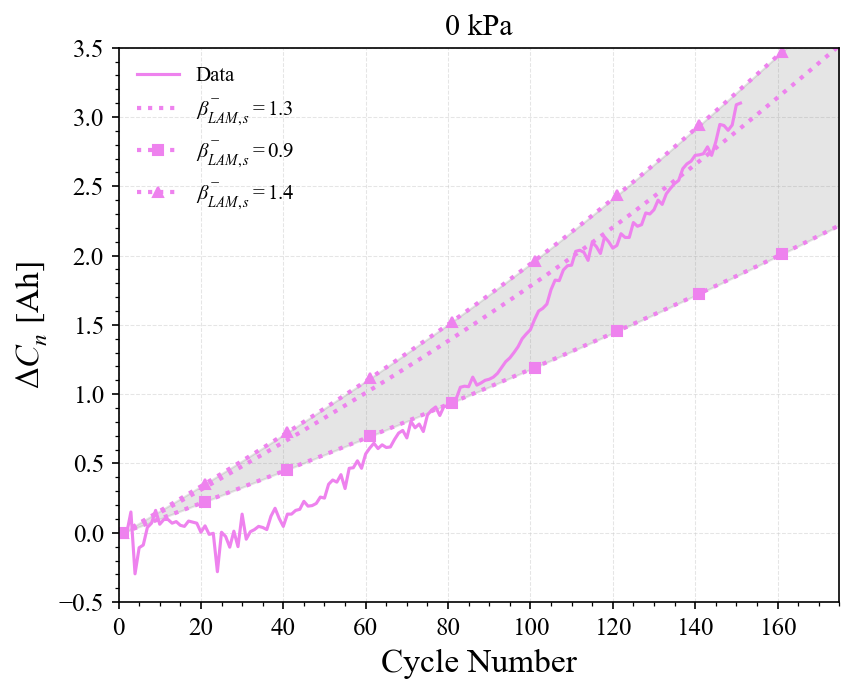

In [53]:
colors = ["violet","salmon","darkorange","red","darkred","black"]
fig, ax = plt.subplots(1,1,figsize=(6.2,4.8))
ax.plot(df0["N"],df0["dq"].iloc[0]/(0.5-0.24)-df0["dq"]/(0.5-0.24),color=colors[0],linewidth=1.5)
i=9
ax.plot(range(1,len(Cn[i])+1),Cn[i][0]-Cn[i],color=colors[0],linestyle='dotted')
i=5
ax.plot(range(1,len(Cn[i])+1),Cn[i][0]-Cn[i],color=colors[0],linestyle='dotted',marker="s",markevery=20)
i=10
ax.plot(range(1,len(Cn[i])+1),Cn[i][0]-Cn[i],color=colors[0],linestyle='dotted',marker="^",markevery=20)
ax.fill_between(range(1,len(Cn[i])+1), Cn[5][0]-Cn[5], Cn[10][0]-Cn[10], color='grey', alpha=0.2, label='Filled Area')
ax.legend(['Data',r'$\beta^-_{LAM,s} = 1.3$',r'$\beta^-_{LAM,s} = 0.9$',r'$\beta^-_{LAM,s} = 1.4$'])
ax.set_ylim([-0.5,3.5])
ax.set_xlabel("Cycle Number",fontsize=16)
ax.set_ylabel(r"$\Delta C_n$ [Ah]",fontsize=16)
ax.set_title("0 kPa")
ax.set_xlim([0,175])
fig.savefig(fig_DIR + f"Expansion_Cn_Pressure_sim_1.png")

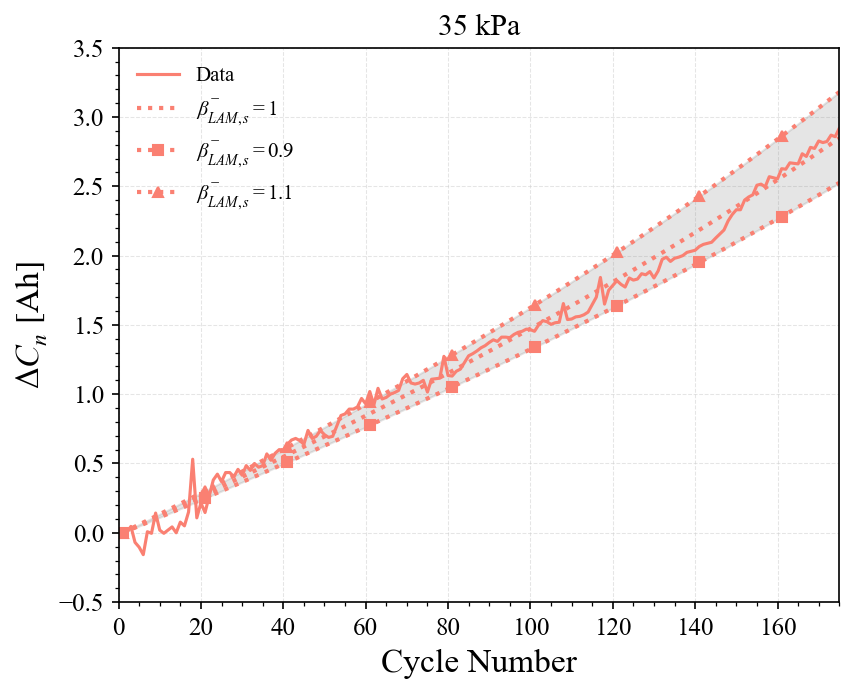

In [52]:
colors = ["violet","salmon","darkorange","red","darkred","black"]
fig, ax = plt.subplots(1,1,figsize=(6.2,4.8))
ax.plot(df1["N"],df1["dq"].iloc[0]/(0.5-0.24)-df1["dq"]/(0.5-0.24),color=colors[1],linewidth=1.5)
i=7
ax.plot(range(1,len(Cn[i])+1),Cn[i][0]-Cn[i],color=colors[1],linestyle='dotted')
i=6
ax.plot(range(1,len(Cn[i])+1),Cn[i][0]-Cn[i],color=colors[1],linestyle='dotted',marker="s",markevery=20)
i=8
ax.plot(range(1,len(Cn[i])+1),Cn[i][0]-Cn[i],color=colors[1],linestyle='dotted',marker="^",markevery=20)
ax.fill_between(range(1,len(Cn[i])+1), Cn[6][0]-Cn[6], Cn[8][0]-Cn[8], color='grey', alpha=0.2, label='Filled Area')
ax.legend(['Data',r'$\beta^-_{LAM,s} = 1$',r'$\beta^-_{LAM,s} = 0.9$',r'$\beta^-_{LAM,s} = 1.1$'])
ax.set_ylim([-0.5,3.5])
ax.set_xlabel("Cycle Number",fontsize=16)
ax.set_ylabel(r"$\Delta C_n$ [Ah]",fontsize=16)
ax.set_title("35 kPa")
ax.set_xlim([0,175])

fig.savefig(fig_DIR + f"Expansion_Cn_Pressure_sim_2.png")

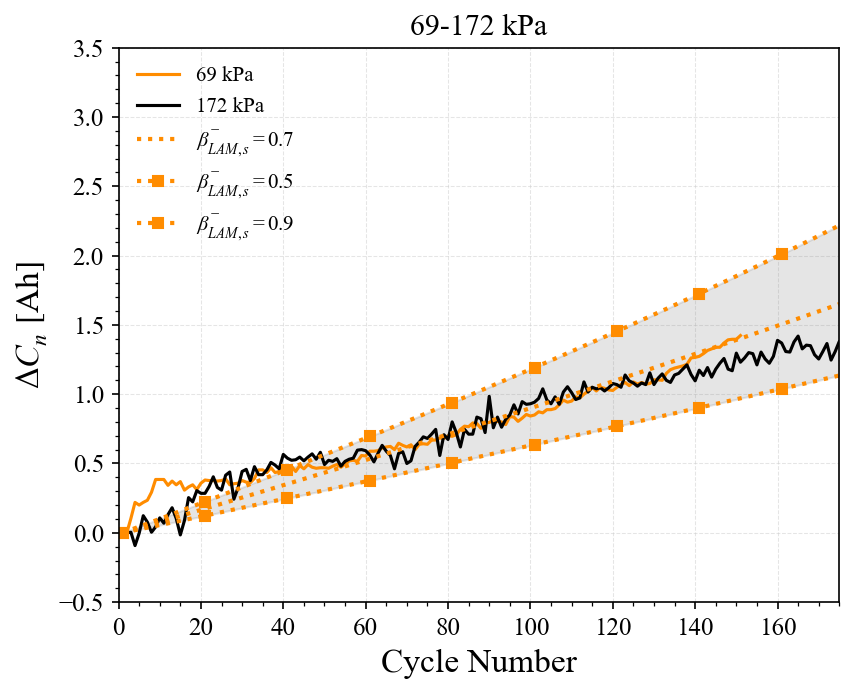

In [51]:
colors = ["violet","salmon","darkorange","red","darkred","black"]

fig, ax = plt.subplots(1,1,figsize=(6.2,4.8))
ax.plot(df2["N"],df2["dq"].iloc[0]/(0.5-0.24)-df2["dq"]/(0.5-0.24),color=colors[2],linewidth=1.5)
# ax.plot(df3["N"],df3["dq"].iloc[0]/(0.5-0.24)-df3["dq"]/(0.5-0.24),color=colors[3],linewidth=1.5)
# ax.plot(df4["N"],df4["dq"].iloc[0]/(0.5-0.24)-df4["dq"]/(0.5-0.24),color=colors[4],linewidth=1.5)
ax.plot(df5["N"],df5["dq"].iloc[0]/(0.5-0.24)-df5["dq"]/(0.5-0.24),color=colors[5],linewidth=1.5)
i=3
ax.plot(range(1,len(Cn[i])+1),Cn[i][0]-Cn[i],color=colors[2],linestyle='dotted')
i=1
ax.plot(range(1,len(Cn[i])+1),Cn[i][0]-Cn[i],color=colors[2],linestyle='dotted',marker="s",markevery=20)
i=5
ax.plot(range(1,len(Cn[i])+1),Cn[i][0]-Cn[i],color=colors[2],linestyle='dotted',marker="s",markevery=20)
ax.fill_between(range(1,len(Cn[i])+1), Cn[1][0]-Cn[1], Cn[5][0]-Cn[5], color='grey', alpha=0.2, label='Filled Area')
ax.legend(['69 kPa','103 kPa','138 kPa','172 kPa'])
ax.legend(['69 kPa','172 kPa',r'$\beta^-_{LAM,s} = 0.7$',r'$\beta^-_{LAM,s} = 0.5$',r'$\beta^-_{LAM,s} = 0.9$'])
ax.set_ylim([-0.5,3.5])
ax.set_xlabel("Cycle Number",fontsize=16)
ax.set_ylabel(r"$\Delta C_n$ [Ah]",fontsize=16)
ax.set_title("69-172 kPa")
ax.set_xlim([0,175])
fig.savefig(fig_DIR + f"Expansion_Cn_Pressure_sim_3.png")

In [ ]:
colors = ["violet","salmon","darkorange","red","darkred","black"]

fig, ax = plt.subplots(1,1,figsize=(6.2,4.8))
# ax.plot(df0["N"],df0["dq"].iloc[0]/(0.5-0.24)-df0["dq"]/(0.5-0.24),color=colors[0],linewidth=1.5)
ax.plot(df1["N"],df1["dq"].iloc[0]/(0.5-0.24)-df1["dq"]/(0.5-0.24),color=colors[1],linewidth=1.5)
# ax.plot(df2["N"],df2["dq"].iloc[0]/(0.5-0.24)-df2["dq"]/(0.5-0.24),color=colors[2],linewidth=1.5)
# ax.plot(df3["N"],df3["dq"].iloc[0]/(0.5-0.24)-df3["dq"]/(0.5-0.24),color=colors[3],linewidth=1.5)
ax.plot(df4["N"],df4["dq"].iloc[0]/(0.5-0.24)-df4["dq"]/(0.5-0.24),color=colors[4],linewidth=1.5)
# ax.plot(df5["N"],df5["dq"].iloc[0]/(0.5-0.24)-df5["dq"]/(0.5-0.24),color=colors[5],linewidth=1.5)
# ax.legend(['0 psi','5 psi','10 psi','15 psi','20 psi','25 psi'])
i=9
# ax.plot(range(1,len(Cn[i])+1),Cn[i][0]-Cn[i],color=colors[0],linestyle='dashed')
i=6
ax.plot(range(1,len(Cn[i])+1),Cn[i][0]-Cn[i],color=colors[1],linestyle='dashed')
i=3
# ax.plot(range(1,len(Cn[i])+1),Cn[i][0]-Cn[i],color=colors[2],linestyle='dashed')
i=3
# ax.plot(range(1,len(Cn[i])+1),Cn[i][0]-Cn[i],color=colors[3],linestyle='dashed')
i=3
ax.plot(range(1,len(Cn[i])+1),Cn[i][0]-Cn[i],color=colors[4],linestyle='dashed')
i=3
# ax.plot(range(1,len(Cn[i])+1),Cn[i][0]-Cn[i],color=colors[5],linestyle='dashed')
ax.legend(['35 kPa','138 kPa','35 kPa sim','138 kPa sim'])
# ax.legend(['0 psi','10 psi','15 psi','20 psi','25 psi','sim'])
# ax.set_ylim([3,6.5])
ax.set_xlabel("Cycle Number",fontsize=16)
ax.set_ylabel(r"$\Delta C_n$",fontsize=16)
# ax.set_title(r"$C_n$",fontsize=16)
fig.savefig(fig_DIR + f"Cn_Pressure_sim_5_20.png")

In [ ]:
colors = ["violet","salmon","darkorange","red","darkred","black"]

fig, ax = plt.subplots(1,1,figsize=(6.2,4.8))
# ax.plot(df0["N"],df0["dq"].iloc[0]/(0.5-0.24)-df0["dq"]/(0.5-0.24),color=colors[0],linewidth=1.5)
ax.plot(df1["N"],df1["dq"].iloc[0]/(0.5-0.24)-df1["dq"]/(0.5-0.24),color=colors[1],linewidth=1.5)
# ax.plot(df2["N"],df2["dq"].iloc[0]/(0.5-0.24)-df2["dq"]/(0.5-0.24),color=colors[2],linewidth=1.5)
# ax.plot(df3["N"],df3["dq"].iloc[0]/(0.5-0.24)-df3["dq"]/(0.5-0.24),color=colors[3],linewidth=1.5)
ax.plot(df4["N"],df4["dq"].iloc[0]/(0.5-0.24)-df4["dq"]/(0.5-0.24),color=colors[4],linewidth=1.5)
# ax.plot(df5["N"],df5["dq"].iloc[0]/(0.5-0.24)-df5["dq"]/(0.5-0.24),color=colors[5],linewidth=1.5)
# ax.legend(['0 psi','5 psi','10 psi','15 psi','20 psi','25 psi'])
i=9
# ax.plot(range(1,len(Cn[i])+1),Cn[i][0]-Cn[i],color=colors[0],linestyle='dashed')
i=6
# ax.plot(range(1,len(Cn[i])+1),Cn[i][0]-Cn[i],color=colors[1],linestyle='dashed')
i=3
# ax.plot(range(1,len(Cn[i])+1),Cn[i][0]-Cn[i],color=colors[2],linestyle='dashed')
i=3
# ax.plot(range(1,len(Cn[i])+1),Cn[i][0]-Cn[i],color=colors[3],linestyle='dashed')
i=6
ax.plot(range(1,len(Cn[i])+1),Cn[i][0]-Cn[i],color=colors[4],linestyle='dashed')
i=3
# ax.plot(range(1,len(Cn[i])+1),Cn[i][0]-Cn[i],color=colors[5],linestyle='dashed')
ax.legend(['35 kPa','138 kPa','35,138 kPa sim','138 kPa sim'])
# ax.legend(['0 psi','10 psi','15 psi','20 psi','25 psi','sim'])
# ax.set_ylim([3,6.5])
ax.set_xlabel("Cycle Number",fontsize=16)
ax.set_ylabel(r"$\Delta C_n$",fontsize=16)
# ax.set_title(r"$C_n$",fontsize=16)
fig.savefig(fig_DIR + f"Cn_Pressure_sim_5_20_mod.png")

In [ ]:
asdfdas

In [ ]:
colors = ["violet","salmon","red","black"]
fig, ax = plt.subplots(1,1,figsize=(6.2,4.8))
ax.plot(df0["N"],df0["dq"].iloc[0]/(0.5-0.24)-df0["dq"]/(0.5-0.24),color=colors[0],linewidth=1.5)
ax.plot(df1["N"],df1["dq"].iloc[0]/(0.5-0.24)-df1["dq"]/(0.5-0.24),color=colors[1],linewidth=1.5)
ax.plot(df3["N"],df3["dq"].iloc[0]/(0.5-0.24)-df3["dq"]/(0.5-0.24),color=colors[2],linewidth=1.5)
ax.plot(df5["N"],df5["dq"].iloc[0]/(0.5-0.24)-df5["dq"]/(0.5-0.24),color=colors[3],linewidth=1.5)
i = 3
ax.plot(range(1,len(Cn[i])+1),Cn[i][0]-Cn[i],color="blue",linestyle='dashed')
# ax.plot(range(1,len(Cn3)+1),Cn3,color=colors[0],linestyle='dashed')
# ax.plot(range(1,len(Cn1)+1),Cn1,color=colors[1],linestyle='dashed')
# # ax.plot(range(1,len(Cn2)+1),Cn2,color=colors[2],linestyle='dashed')
# ax.plot(range(1,len(Cn5)+1),Cn5,color=colors[2],linestyle='dashed')
# ax.plot(range(1,len(Cn6)+1),Cn6,color=colors[3],linestyle='dashed')
# ax.legend(['0 psi','5 psi','10 psi','15 psi','20 psi','25 psi','0 sim','5 sim', '10 sim','20 sim','25 sim'])
ax.legend(['0 kPa data','35 kPa data','103 kPa data','173 kPa data','0 kPa sim','35 kPa sim','103 kPa sim','173 kPa sim'])
# ax.legend(['0 psi','10 psi','15 psi','20 psi','25 psi','sim'])
# ax.set_ylim([0.5,2])
# ax.set_ylim([3,6.5])
ax.set_xlabel("Cycle Number",fontsize=16)
ax.set_ylabel(r"$C_n$",fontsize=16)
ax.set_title(r"$C_n$ Data vs Simulation",fontsize=16)
fig.savefig(fig_DIR + f"Expansion_Cn_Pressure_sim.png")

In [ ]:
fig, ax = plt.subplots(1,1, sharex=True, figsize=(5,4))
x1 = [0 ,35 ,69 ,103 ,138 ,172 ]
x2 = [xs[9-1],xs[6-1],xs[3-1],xs[3-1],xs[3-1],xs[3-1],]
# x3 = [5/xi for xi in x1]
# x3[0] = np.nan
ax.plot(x1,x2,'x-')
ax.set_title(r"Mechanical Damage Scaling vs Pressure")
ax.set_xlabel("Pressure (kPa)")
ax.set_ylabel(r"$\beta^-_{LAM,s}$ Scaling")
plt.savefig(fig_DIR + "beta vs pressure.png")

In [ ]:
fig, ax = plt.subplots(1,1, sharex=True, figsize=(6.2,4.8))
x1 = [0 ,35 ,69 ,103 ,138 ,172 ]
x2 = [xs[9-1],xs[6-1],xs[3-1],xs[3-1],xs[3-1],xs[3-1],]
# x3 = [5/xi for xi in x1]
# x3[0] = np.nan
# ax.plot(x1,x2,'x-')
yerr1 = [0.4,0.1,0.2,0.2,0.2,0.2]
yerr2 = [0.1,0.1,0.2,0.2,0.2,0.2]
xerr = [5,5,5,5,5,5]

ax.errorbar(x1,x2,yerr=[yerr1, yerr2],fmt='o-',capsize =3,elinewidth=1,ecolor="black")
ax.set_title(r"Mechanical Damage Scaling vs Pressure")
ax.set_xlabel("Pressure (kPa)")
ax.set_ylabel(r"$\beta^-_{LAM,s}$ Scaling")
plt.savefig(fig_DIR + "beta vs pressure.png")

In [ ]:
fig, ax = plt.subplots(1,1, sharex=True, figsize=(5,4))
x1 = [0 ,35 ,69 ,103 ,138 ,172 ]
x2 = [xs[9-1],xs[6-1],xs[3-1],xs[3-1],xs[6-1],xs[3-1],]
# x3 = [5/xi for xi in x1]
# x3[0] = np.nan
ax.plot(x1,x2,'x-')
ax.set_title(r"Mechanical Damage Scaling vs Pressure")
ax.set_xlabel("Pressure (kPa)")
ax.set_ylabel(r"$\beta^-_{LAM,s}$ Scaling")
plt.savefig(fig_DIR + "beta vs pressure mod.png")

## Aging Sims

In [ ]:
cell = 26
dfe0=pd.read_csv(eSOH_DIR+f"aging_param_cell_cyc_{cell:02d}.csv")
dfe0 = dfe0.iloc[1:]
# cell = 28
# dfe1=pd.read_csv(eSOH_DIR+f"aging_param_cell_cyc_{cell:02d}.csv")
cell = 9
dfe1=pd.read_csv(eSOH_DIR+f"aging_param_cell_cyc_{cell:02d}.csv")
tt = dfe1["Min Exp [mu m]"]
tt = tt.to_numpy()
idx = np.where(np.diff(tt)<0)
for i in idx:
    dfe1["Min Exp [mu m]"].iloc[i+1]=dfe1["Min Exp [mu m]"].iloc[i]
cell = 29
dfe2=pd.read_csv(eSOH_DIR+f"aging_param_cell_cyc_{cell:02d}.csv")
cell = 31
dfe3=pd.read_csv(eSOH_DIR+f"aging_param_cell_cyc_{cell:02d}.csv")
cell = 33
dfe4=pd.read_csv(eSOH_DIR+f"aging_param_cell_cyc_{cell:02d}.csv")
cell = 35
dfe5=pd.read_csv(eSOH_DIR+f"aging_param_cell_cyc_{cell:02d}.csv")



In [ ]:
colors = ["violet","salmon","darkorange","red","darkred","black"]

In [ ]:
fig, ax = plt.subplots(1,1, sharex=True, figsize=(5,5))
i = 0 
# df = dfe0
# ax.plot(df['N'].iloc[:50],-df['App Cap [Ah]'].iloc[:50]+df['App Cap [Ah]'].iloc[0],color=colors[i],linestyle='solid')
# ax.plot(df['N'].iloc[50:],-df['App Cap [Ah]'].iloc[50:]+df['App Cap [Ah]'].iloc[0],color="darkgrey",linestyle='solid',label='_nolegend_')
# i+=1
for df in [dfe0,dfe1,dfe2,dfe3,dfe4,dfe5]:
    ax.plot(df['N'],-df['App Cap [Ah]']+df['App Cap [Ah]'].iloc[0],color=colors[i],linestyle='solid')
    i+=1

# for Ql in [Q[9],Q[6],Q[3],Q[3],Q[3],Q[3]]:
#     ax.plot(range(1,len(Ql)+1),-Ql+Ql[0],color=colors[i],linestyle='dashed')
#     i+=1
i = 0 
for Ql in [Q[9],Q[6],Q[3]]:
    ax.plot(range(1,len(Ql)+1),-Ql+Ql[0],color=colors[i],linestyle='dashed')
    i+=1
# ax.set_title("Apparent Capacity Loss")
ax.set_xlabel("Cycle Number",fontsize=14)
# ax.set_ylabel(r"$\Delta Q_{app}$ [$Ah$]",fontsize=14)
ax.set_ylabel(r"Capacity Loss in Ah",fontsize=14)
# ax.legend(['0 kPa','35 kPa','69 kPa','103 kPa','138 kPa','172 kPa','0 kPa sim','35 kPa sim','69 kPa sim','103 kPa sim','138 kPa sim','172 kPa sim'])
# ax.legend(['0 kPa','35 kPa','69 kPa','103 kPa','138 kPa','172 kPa','0 kPa sim','35 kPa sim','69,103,138,172 kPa sim'])
ax.set_ylim(bottom=0)
ax2 = ax.twinx()
i = 0 
for df in [dfe0,dfe1,dfe2,dfe3,dfe4,dfe5]:
    ax2.plot(df['N'],(-df['App Cap [Ah]']+df['App Cap [Ah]'].iloc[0])/5*100,color=colors[i],linestyle='solid')
    i+=1
ax2.set_ylim(bottom=0)
ax2.set_ylabel(r"Capacity Loss in % of Nominal Capacity",fontsize=14)
# plt.savefig(fig_DIR + "Hot Cap Sim_1.png")

In [ ]:
fig, ax = plt.subplots(1,1, sharex=True,figsize=(6.2,4.8))
i = 0 
# for df in [dfe0,dfe1,dfe2,dfe3,dfe4,dfe5]:
df = dfe1
ax.plot(df['N'],-df['App Cap [Ah]']+df['App Cap [Ah]'].iloc[0],color=colors[1],linestyle='solid')
df = dfe4
ax.plot(df['N'],-df['App Cap [Ah]']+df['App Cap [Ah]'].iloc[0],color=colors[4],linestyle='solid')

# Ql = Q[6]
# ax.plot(range(1,len(Ql)+1),-Ql+Ql[0],color=colors[1],linestyle='dashed')
Ql = Q[6]
ax.plot(range(1,len(Ql)+1),-Ql+Ql[0],color=colors[4],linestyle='dashed')
# ax.set_title("Apparent Capacity Loss")
ax.set_xlabel("Cycle Number",fontsize=16)
ax.set_ylabel(r"$\Delta Q_{app}$ [$Ah$]",fontsize=16)
ax.legend(['35 kPa','138 kPa','35,138 kPa sim','138 kPa sim'])
ax.set_ylim(bottom=0)
plt.savefig(fig_DIR + "Hot Cap Sim_5_20_mod.png")

In [ ]:
fig, ax = plt.subplots(1,1, sharex=True,figsize=(6.2,4.8))
i = 0 
# for df in [dfe0,dfe1,dfe2,dfe3,dfe4,dfe5]:
df = dfe1
ax.plot(df['N'],-df['App Cap [Ah]']+df['App Cap [Ah]'].iloc[0],color=colors[1],linestyle='solid')
df = dfe4
ax.plot(df['N'],-df['App Cap [Ah]']+df['App Cap [Ah]'].iloc[0],color=colors[4],linestyle='solid')

Ql = Q[6]
ax.plot(range(1,len(Ql)+1),-Ql+Ql[0],color=colors[1],linestyle='dashed')
Ql = Q[3]
ax.plot(range(1,len(Ql)+1),-Ql+Ql[0],color=colors[4],linestyle='dashed')
# ax.set_title("Apparent Capacity Loss")
ax.set_xlabel("Cycle Number",fontsize=16)
ax.set_ylabel(r"$\Delta Q_{app}$ [$Ah$]",fontsize=16)
ax.legend(['35 kPa','138 kPa','35 kPa sim','138 kPa sim'])
ax.set_ylim(bottom=0)
plt.savefig(fig_DIR + "Hot Cap Sim_5_20.png")

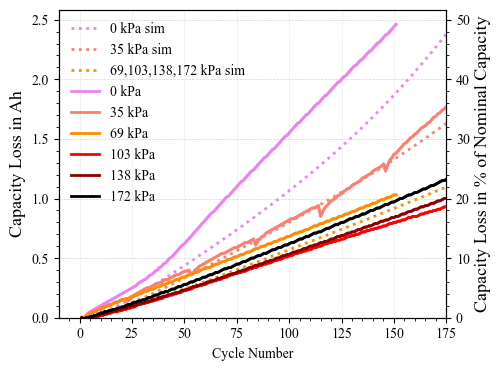

In [33]:
fig, ax = plt.subplots(1,1, sharex=True, figsize=(5,4))
i = 0 
for Ql in [Q[9],Q[6],Q[3]]:
    ax.plot(range(1,len(Ql)+1),-Ql+Ql[0],color=colors[i],linestyle='dotted')
    i+=1

i = 0 
for df in [dfe0,dfe1,dfe2,dfe3,dfe4,dfe5]:
    ax.plot(df['N'],-df['App Cap [Ah]']+df['App Cap [Ah]'].iloc[0],color=colors[i],linestyle='solid')
    i+=1
# for Ql in [Q[9],Q[6],Q[3],Q[3],Q[3],Q[3]]:
#     ax.plot(range(1,len(Ql)+1),-Ql+Ql[0],color=colors[i],linestyle='dotted')
#     i+=1

# ax.set_title("Apparent Capacity Loss")
ax.set_xlabel("Cycle Number")
# ax.set_ylabel(r"$\Delta Q_{app}$ [$Ah$]")
ax.set_ylabel(r"Capacity Loss in Ah",fontsize=13)
ax.legend(['0 kPa','35 kPa','69 kPa','103 kPa','138 kPa','172 kPa','0 kPa sim','35 kPa sim','69 kPa sim','103 kPa sim','138 kPa sim','172 kPa sim'])
ax.legend(['0 kPa','35 kPa','69 kPa','103 kPa','138 kPa','172 kPa','0 kPa sim','35 kPa sim','69,103,138,172 kPa sim'])
ax.legend(['0 kPa sim','35 kPa sim','69,103,138,172 kPa sim','0 kPa','35 kPa','69 kPa','103 kPa','138 kPa','172 kPa'])
ax.set_ylim(bottom=0)
ax2 = ax.twinx()
i = 0 
for df in [dfe0,dfe1,dfe2,dfe3,dfe4,dfe5]:
    ax2.plot(df['N'],(-df['App Cap [Ah]']+df['App Cap [Ah]'].iloc[0])/5*100,color=colors[i],linestyle='solid')
    i+=1
ax2.set_ylim(bottom=0)
ax.set_xlim(right=175)

ax2.set_ylabel(r"Capacity Loss in % of Nominal Capacity",fontsize=13)
plt.savefig(fig_DIR + "Hot Cap Sim_1.png")

In [ ]:


fig, ax = plt.subplots(1,1, sharex=True, figsize=(10,10))
i = 0
# df = dfe0
# ax.plot(df['N'].iloc[:50],df['Rs [ohm]'].iloc[:50]-df['Rs [ohm]'].iloc[0],color=colors[i],linestyle='solid')
# ax.plot(df['N'].iloc[50:],df['Rs [ohm]'].iloc[50:]-df['Rs [ohm]'].iloc[0],color="darkgrey",linestyle='solid',label='_nolegend_')
# i+=1
for df in [dfe0,dfe1,dfe2,dfe3,dfe4,dfe5]:
    
    if i == 3:
        ax.plot(df['N'],df['Rs [ohm]']-df['Rs [ohm]'].iloc[2],color=colors[i],linestyle='solid')
    elif i == 4:
        ax.plot(df['N'],df['Rs [ohm]']-df['Rs [ohm]'].iloc[1],color=colors[i],linestyle='solid')
    else:
        ax.plot(df['N'],df['Rs [ohm]']-df['Rs [ohm]'].iloc[0],color=colors[i],linestyle='solid')
    i+=1
i = 0 
# for Rsl in [Rs[9],Rs[6],Rs[3],Rs[3],Rs[3],Rs[3]]:
for Rsl in [Rs[9],Rs[6],Rs[3]]:
    ax.plot(range(1,len(Rsl)+1),Rsl-Rsl[0],color=colors[i],linestyle='dashed')
    i+=1
# ax.set_title("Resistance Growth")
ax.set_xlabel("Cycle Number",fontsize=14)
ax.set_ylabel(r"$\Delta R_s$ [$\Omega$]",fontsize=14)
# ax.legend(['0 kPa','35 kPa','69 kPa','103 kPa','138 kPa','172 kPa','0 kPa sim','35 kPa sim','69 kPa sim','103 kPa sim','138 kPa sim','172 kPa sim'])
ax.legend(['0 kPa','35 kPa','69 kPa','103 kPa','138 kPa','172 kPa','0 kPa sim','35 kPa sim','69,103,138,172 kPa sim'],ncol=3,loc="upper left")
plt.grid(False)
ax.set_ylim(bottom=0)
plt.savefig(fig_DIR + "Hot Sim Legend.png")


In [ ]:


fig, ax = plt.subplots(1,1, sharex=True, figsize=(5,4))
i = 0
# df = dfe0
# ax.plot(df['N'].iloc[:50],df['Rs [ohm]'].iloc[:50]-df['Rs [ohm]'].iloc[0],color=colors[i],linestyle='solid')
# ax.plot(df['N'].iloc[50:],df['Rs [ohm]'].iloc[50:]-df['Rs [ohm]'].iloc[0],color="darkgrey",linestyle='solid')
# i+=1
for Rsl in [Rs[9],Rs[6],Rs[3]]:
    ax.plot(range(1,len(Rsl)+1),(Rsl-Rsl[0])*1000,color=colors[i],linestyle='dotted')
    i+=1

i = 0 
for df in [dfe0,dfe1,dfe2,dfe3,dfe4,dfe5]:
    
    if i == 3:
        ax.plot(df['N'],(df['Rs [ohm]']-df['Rs [ohm]'].iloc[2])*1000,color=colors[i],linestyle='solid')
    elif i == 4:
        ax.plot(df['N'],(df['Rs [ohm]']-df['Rs [ohm]'].iloc[1])*1000,color=colors[i],linestyle='solid')
    else:
        ax.plot(df['N'],(df['Rs [ohm]']-df['Rs [ohm]'].iloc[0])*1000,color=colors[i],linestyle='solid')
    i+=1
# for Rsl in [Rs[9],Rs[6],Rs[3],Rs[3],Rs[3],Rs[3]]:

# ax.set_title("Resistance Growth")
ax.set_xlabel("Cycle Number",fontsize=14)
# ax.set_ylabel(r"$\Delta R_s$ [$\Omega$]",fontsize=14)
ax.set_ylabel(r"Resistance Growth in m$\Omega$",fontsize=14)

# ax.legend(['0 kPa','35 kPa','69 kPa','103 kPa','138 kPa','172 kPa','0 kPa sim','35 kPa sim','69 kPa sim','103 kPa sim','138 kPa sim','172 kPa sim'])
# ax.legend(['0 kPa','35 kPa','69 kPa','103 kPa','138 kPa','172 kPa','0 kPa sim','35 kPa sim','69,103,138,172 kPa sim'],ncol=2,loc="upper left")
ax.legend(['0 kPa','35 kPa','69 kPa','103 kPa','138 kPa','172 kPa','0 kPa sim','35 kPa sim','69,103,138,172 kPa sim'])
ax.legend(['0 kPa sim','35 kPa sim','69,103,138,172 kPa sim','0 kPa','35 kPa','69 kPa','103 kPa','138 kPa','172 kPa'])
ax.set_ylim(bottom=0)
ax2 = ax.twinx()
i = 0
# df = dfe0
# ax.plot(df['N'].iloc[:50],df['Rs [ohm]'].iloc[:50]-df['Rs [ohm]'].iloc[0],color=colors[i],linestyle='solid')
# ax.plot(df['N'].iloc[50:],df['Rs [ohm]'].iloc[50:]-df['Rs [ohm]'].iloc[0],color="darkgrey",linestyle='solid')
# i+=1
for df in [dfe0,dfe1,dfe2,dfe3,dfe4,dfe5]:
    
    if i == 3:
        ax2.plot(df['N'],(df['Rs [ohm]']-df['Rs [ohm]'].iloc[2])*100/0.0075,color=colors[i],linestyle='solid')
    elif i == 4:
        ax2.plot(df['N'],(df['Rs [ohm]']-df['Rs [ohm]'].iloc[1])*100/0.0075,color=colors[i],linestyle='solid')
    else:
        ax2.plot(df['N'],(df['Rs [ohm]']-df['Rs [ohm]'].iloc[0])*100/0.0075,color=colors[i],linestyle='solid')
    i+=1
i = 0 
# for Rsl in [Rs[9],Rs[6],Rs[3],Rs[3],Rs[3],Rs[3]]:
for Rsl in [Rs[9],Rs[6],Rs[3]]:
    ax2.plot(range(1,len(Rsl)+1),(Rsl-Rsl[0])*100/0.0075,color=colors[i],linestyle='dotted')
    i+=1
ax2.set_ylim(bottom=0)
ax.set_xlim(right=175)

ax2.set_ylabel(r"Resistance Growth in % of Nominal Resistance",fontsize=12)
plt.savefig(fig_DIR + "Hot Resistance Sim_1.png")

In [ ]:


fig, ax = plt.subplots(1,1, sharex=True, figsize=(5,5))
i = 0
# df = dfe0
# ax.plot(df['N'].iloc[:50],df['Rs [ohm]'].iloc[:50]-df['Rs [ohm]'].iloc[0],color=colors[i],linestyle='solid')
# ax.plot(df['N'].iloc[50:],df['Rs [ohm]'].iloc[50:]-df['Rs [ohm]'].iloc[0],color="darkgrey",linestyle='solid')
# i+=1
for df in [dfe0,dfe1,dfe2,dfe3,dfe4,dfe5]:
    
    if i == 3:
        ax.plot(df['N'],df['Rs [ohm]']-df['Rs [ohm]'].iloc[2],color=colors[i],linestyle='solid')
    elif i == 4:
        ax.plot(df['N'],df['Rs [ohm]']-df['Rs [ohm]'].iloc[1],color=colors[i],linestyle='solid')
    else:
        ax.plot(df['N'],df['Rs [ohm]']-df['Rs [ohm]'].iloc[0],color=colors[i],linestyle='solid')
    i+=1
i = 0 
# for Rsl in [Rs[9],Rs[6],Rs[3],Rs[3],Rs[3],Rs[3]]:
for Rsl in [Rs[9],Rs[6],Rs[3]]:
    ax.plot(range(1,len(Rsl)+1),Rsl-Rsl[0],color=colors[i],linestyle='dashed')
    i+=1
# ax.set_title("Resistance Growth")
ax.set_xlabel("Cycle Number",fontsize=14)
ax.set_ylabel(r"$\Delta R_s$ [$\Omega$]",fontsize=14)
# ax.legend(['0 kPa','35 kPa','69 kPa','103 kPa','138 kPa','172 kPa','0 kPa sim','35 kPa sim','69 kPa sim','103 kPa sim','138 kPa sim','172 kPa sim'])
# ax.legend(['0 kPa','35 kPa','69 kPa','103 kPa','138 kPa','172 kPa','0 kPa sim','35 kPa sim','69,103,138,172 kPa sim'],ncol=2,loc="upper left")
ax.set_ylim(bottom=0)
plt.savefig(fig_DIR + "Hot Resistance Sim_1.png")


In [ ]:
colors = ["violet","salmon","darkorange","red","darkred","black"]
fig, ax = plt.subplots(1,1, sharex=True, figsize=(5,4))
i = 0
for El in [E[9],E[6],E[3]]:
    ax.plot(range(1,len(El)+1),El,color=colors[i],linestyle='dotted')
    i+=1
# df = dfe0
# ax.plot(df['N'].iloc[:50],df['Min Exp [mu m]'].iloc[:50]-df['Min Exp [mu m]'].iloc[0],color=colors[i],linestyle='solid')
# ax.plot(df['N'].iloc[50:],df['Min Exp [mu m]'].iloc[50:]-df['Min Exp [mu m]'].iloc[0],color="darkgrey",linestyle='solid')
# i+=1

i = 0
for df in [dfe0,dfe1,dfe2,dfe3,dfe4,dfe5]:
    ax.plot(df['N'],df['Min Exp [mu m]']-df['Min Exp [mu m]'].iloc[0],color=colors[i],linestyle='solid')
    i+=1
# for El in [E[9],E[6],E[3],E[3],E[3],E[3]]:

# ax.plot(range(1,len(sols3)+1),E3,color=colors(nc[0]),linestyle='dotted')
# ax.plot(range(1,len(sols1)+1),E1,color=colors(nc[1]),linestyle='dotted')
# ax.plot(range(1,len(sols2)+1),E2,color=colors(nc[2]),linestyle='dotted')
# ax.plot(range(1,len(sols5)+1),E5,color=colors(nc[3]),linestyle='dotted')
# ax.plot(range(1,len(sols6)+1),E6,color=colors(nc[5]),linestyle='dotted')
# ax.set_title("Irreversible Expansion")
ax.set_xlabel("Cycle Number",fontsize=14)

# ax.set_ylabel(r"$\delta$ [$\mu$m]",fontsize=14)
ax.set_ylabel(r"Irrev. Exp. in $\mu$m",fontsize=14)

# ax.legend(['0 kPa','35 kPa','69 kPa','103 kPa','138 kPa','172 kPa','0 kPa sim','35 kPa sim','69 kPa sim','103 kPa sim','138 kPa sim','172 kPa sim'])
ax.legend(['0 kPa','35 kPa','69 kPa','103 kPa','138 kPa','172 kPa','0 kPa sim','35 kPa sim','69,103,138,172 kPa sim'])
ax.legend(['0 kPa sim','35 kPa sim','69,103,138,172 kPa sim','0 kPa','35 kPa','69 kPa','103 kPa','138 kPa','172 kPa'])


# ax.legend(['0 psi','5 psi','10 psi','15 psi','20 psi','25 psi','0 sim','5 sim', '10 sim','15 sim', '25 sim'])
ax.set_ylim(bottom=0)
ax.set_xlim(right=175)
ax2 = ax.twinx()
i = 0
for df in [dfe0,dfe1,dfe2,dfe3,dfe4,dfe5]:
    ax2.plot(df['N'],(df['Min Exp [mu m]']-df['Min Exp [mu m]'].iloc[0])*100/4000,color=colors[i],linestyle='solid')
    i+=1
ax2.set_ylim(bottom=0)
ax2.set_ylabel(r"Irrev. Exp. in % of Nominal Battery Thickness",fontsize=12)
plt.savefig(fig_DIR + "Hot Exp Sim_1.png")

### Defense Plots

In [ ]:
fig, ax = plt.subplots(1,1, sharex=True, figsize=(5,5))
i = 0 
for df in [dfe0,dfe1,dfe2,dfe3,dfe4,dfe5]:
    ax.plot(df['N'],-df['App Cap [Ah]']+df['App Cap [Ah]'].iloc[0],color=colors[i],linestyle='solid')
    i+=1
i = 0 
for Ql in [Q[9],Q[6],Q[3]]:
    ax.plot(range(1,len(Ql)+1),-Ql+Ql[0],color=colors[i],linestyle='dashed')
    i+=1
ax.set_xlabel("Cycle Number",fontsize=14)
ax.set_ylabel(r"$\Delta Q_{app}$ [$Ah$]",fontsize=14)
ax.set_ylim(bottom=0)
plt.savefig(fig_DIR + "Hot Cap Sim_3.png")

In [ ]:
fig, ax = plt.subplots(1,1, sharex=True, figsize=(5,5))
i = 0
for df in [dfe0,dfe1,dfe2,dfe3,dfe4,dfe5]:
    
    if i == 3:
        ax.plot(df['N'],df['Rs [ohm]']-df['Rs [ohm]'].iloc[2],color=colors[i],linestyle='solid')
    elif i == 4:
        ax.plot(df['N'],df['Rs [ohm]']-df['Rs [ohm]'].iloc[1],color=colors[i],linestyle='solid')
    else:
        ax.plot(df['N'],df['Rs [ohm]']-df['Rs [ohm]'].iloc[0],color=colors[i],linestyle='solid')
    i+=1
i = 0 
for Rsl in [Rs[9],Rs[6],Rs[3]]:
    ax.plot(range(1,len(Rsl)+1),Rsl-Rsl[0],color=colors[i],linestyle='dashed')
    i+=1
ax.set_xlabel("Cycle Number",fontsize=14)
ax.set_ylabel(r"$\Delta R_s$ [$\Omega$]",fontsize=14)

ax.set_ylim(bottom=0)
plt.savefig(fig_DIR + "Hot Resistance Sim_3.png")

In [ ]:
colors = ["violet","salmon","darkorange","red","darkred","black"]
fig, ax = plt.subplots(1,1, sharex=True, figsize=(5,5))
i = 0
for df in [dfe0,dfe1,dfe2,dfe3,dfe4,dfe5]:
    ax.plot(df['N'],df['Min Exp [mu m]']-df['Min Exp [mu m]'].iloc[0],color=colors[i],linestyle='solid')
    i+=1
i = 0
for El in [E[9],E[6],E[3]]:
    ax.plot(range(1,len(El)+1),El,color=colors[i],linestyle='dashed')
    i+=1
ax.set_xlabel("Cycle Number",fontsize=14)
ax.set_ylabel(r"$\delta$ [$\mu$m]",fontsize=14)
ax.set_ylim(bottom=0)
plt.savefig(fig_DIR + "Hot Exp Sim_3.png")

In [ ]:
sadfsd

### Repeat Cells for thesis

In [ ]:
cell = 9
dfe1=pd.read_csv(eSOH_DIR+f"aging_param_cell_cyc_{cell:02d}.csv")
tt = dfe1["Min Exp [mu m]"]
tt = tt.to_numpy()
idx = np.where(np.diff(tt)<0)
for i in idx:
    dfe1["Min Exp [mu m]"].iloc[i+1]=dfe1["Min Exp [mu m]"].iloc[i]
dfe1_1 = dfe1.copy()

cell = 27
dfe1_2=pd.read_csv(eSOH_DIR+f"aging_param_cell_cyc_{cell:02d}.csv")
cell = 28
dfe1_3=pd.read_csv(eSOH_DIR+f"aging_param_cell_cyc_{cell:02d}.csv")

In [ ]:
# Capacity
fig, ax = plt.subplots(1,1, sharex=True, figsize=(5,5))
i = 0 
for df in [dfe1_1,dfe1_2,dfe1_3]:
    ax.plot(df['N'],-df['App Cap [Ah]']+df['App Cap [Ah]'].iloc[0],linestyle='solid')
ax.set_xlabel("Cycle Number",fontsize=14)
ax.set_ylabel(r"$\Delta Q_{app}$ [$Ah$]",fontsize=14)
ax.set_ylim(bottom=0)
ax.legend(["Cell 9 (RPT)","Cell 27","Cell 28"])
plt.savefig(fig_DIR + "Hot Cap Sim_3_repeat.png")

In [ ]:
# Resistance
fig, ax = plt.subplots(1,1, sharex=True, figsize=(5,5))
i = 0
for df in [dfe1_1,dfe1_2,dfe1_3]:
    ax.plot(df['N'],df['Rs [ohm]']-df['Rs [ohm]'].iloc[0],linestyle='solid')

ax.set_xlabel("Cycle Number",fontsize=14)
ax.set_ylabel(r"$\Delta R_s$ [$\Omega$]",fontsize=14)

ax.set_ylim(bottom=0)
plt.savefig(fig_DIR + "Hot Resistance Sim_3_repeat.png")

In [ ]:
# Expansion
fig, ax = plt.subplots(1,1, sharex=True, figsize=(5,5))
i = 0
for df in [dfe1_1,dfe1_2,dfe1_3]:
    ax.plot(df['N'],df['Min Exp [mu m]']-df['Min Exp [mu m]'].iloc[0],linestyle='solid')

ax.set_xlabel("Cycle Number",fontsize=14)
ax.set_ylabel(r"$\delta$ [$\mu$m]",fontsize=14)
ax.set_ylim(bottom=0)
plt.savefig(fig_DIR + "Hot Exp Sim_3_repeat.png")

### Errors

In [ ]:
df =dfe1
tt = df['Min Exp [mu m]']-df['Min Exp [mu m]'].iloc[0]
tt = tt.to_numpy()
idx = np.where(np.diff(tt)<0)
for i in idx:
    tt[i+1]=tt[i]
El = E[6]
ln = min(len(tt),len(El))
pybamm.rmse(tt[:ln],El[:ln])

In [ ]:
fig,ax = plt.subplots(1,1)
ax.plot(tt)

In [ ]:
def get_exp_error(df,El):
    tt = df['Min Exp [mu m]']-df['Min Exp [mu m]'].iloc[0]
    tt = tt.to_numpy()
    ln = min(len(tt),len(El))
    return pybamm.rmse(tt[:ln],El[:ln])
def get_res_error(df,Rs,of=0):
    tt = df['Rs [ohm]']-df['Rs [ohm]'].iloc[of]
    tt = tt.to_numpy()
    rr = Rsl-Rsl[0]
    ln = min(len(tt),len(rr))
    return pybamm.rmse(tt[:ln],rr[:ln])*1000
def get_cap_error(df,Ql):
    tt = -df['App Cap [Ah]']+df['App Cap [Ah]'].iloc[0]
    tt = tt.to_numpy()
    rr = -Ql+Ql[0]
    ln = min(len(tt),len(rr))
    return pybamm.rmse(tt[:ln],rr[:ln])

In [ ]:
df=dfe3
i=3
print(get_cap_error(df,Q[i]))
print(get_res_error(df.iloc[2:],Rs[i][2:],0))
print(get_exp_error(df,E[i]))
